### 聊天模型包装器

LangChain作为一个应用开发框架，需要集成各种不同的大模型，通过Message数据输入规范，定义不同的role来区分对话过程。LangChain目前就抽象出来的角色消息类型有 AIMessage 、 HumanMessage 、 SystemMessage 和FunctionMessage，但大多时候我们只需要处理 HumanMessage 、 AIMessage 和 SystemMessage，即：

- SystemMessage ：用于启动 AI 行为，作为输入消息序列中的第一个传入。
- HumanMessage ：表示来自与聊天模型交互的人的消息。
- AIMessage ：表示来自聊天模型的消息。这可以是文本，也可以是调用工具的请求。

因此我们需要导入如下模块：

In [1]:
from langchain_openai import OpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI

**消息形式输入调用**

- 定义消息对象：

In [2]:
messages = [SystemMessage(content="你是个取名大师，你擅长为创业公司取名字"),
HumanMessage(content="帮我给信公司取个名字，要包含AI"),]

- 执行推理：

In [5]:
API_KEY = open('./key_files/deepseekAPI-Key.md').readline().strip()
chat = ChatOpenAI(model_name="deepseek-chat",
                  api_key=API_KEY,base_url="https://api.deepseek.com")
reponse = chat.invoke(messages) #处理单条输入

In [6]:
#如果只想获取到纯净的输出，可以通过.content来格式化
reponse.content

'1. 智联未来（AI-Link Future）\n2. 慧算无界（WiseBound AI）\n3. 睿思智创（RuiThink AI）\n4. 数智方舟（DataArk AI）\n5. 灵犀智算（LingXi AI）\n6. 智汇云图（AI-Cloud Atlas）\n7. 深维智能（DeepDimen AI）\n8. 天工智算（TianGong AI）\n9. 量子智联（Quantum AI Link）\n10. 智启星辰（AI-Stellar）'

批量调用

- 先定义三个不同的消息对象：

In [7]:
messages1 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
HumanMessage(content="请帮我介绍一下什么是机器学习"),]

messages2 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
HumanMessage(content="请帮我介绍一下什么是深度学习"),]

messages3 = [SystemMessage(content="你是一位乐于助人的智能小助手"),
HumanMessage(content="请帮我介绍一下什么是大模型技术"),]

- 将上述三个消息对象放在一个列表中，使用.batch方法执行批量调用

In [8]:
reponse = chat.batch([messages1,
            messages2,
            messages3,])
# 格式化输出：使用列表生成式打印每一个消息的内容
contents = [msg.content for msg in reponse]
# 打印出内容
for content in contents:
    print(content, "\n---\n")

机器学习（Machine Learning, ML）是人工智能（AI）的一个核心分支，其核心目标是让计算机系统能够通过数据**自动学习和改进**，而无需显式编程。简单来说，机器学习通过算法从历史数据中挖掘规律（或模式），并利用这些规律对新数据做出预测或决策。

---

### **关键概念**
1. **核心思想**  
   - 传统编程：人类编写规则，计算机执行。  
   - 机器学习：计算机从数据中自动推导规则（模型），并不断优化。

2. **基本流程**  
   - **数据输入**：收集高质量数据（如图像、文本、数值等）。  
   - **特征提取**：选择或自动识别数据中的关键特征（如像素值、关键词）。  
   - **模型训练**：通过算法（如神经网络、决策树）学习数据中的模式。  
   - **预测/决策**：将训练好的模型应用于新数据（如分类、回归）。

---

### **主要类型**
1. **监督学习（Supervised Learning）**  
   - 数据带有标签（正确答案），模型学习输入到输出的映射。  
   - **例子**：垃圾邮件分类、房价预测。  
   - **常用算法**：线性回归、支持向量机（SVM）、深度学习。

2. **无监督学习（Unsupervised Learning）**  
   - 数据无标签，模型自行发现隐藏结构。  
   - **例子**：客户分群、异常检测。  
   - **常用算法**：K均值聚类、主成分分析（PCA）。

3. **强化学习（Reinforcement Learning）**  
   - 模型通过与环境交互获取反馈（奖励/惩罚），优化策略。  
   - **例子**：AlphaGo、自动驾驶。  

4. **其他类型**  
   - 半监督学习（部分数据有标签）、迁移学习（复用预训练模型）等。

---

### **典型应用场景**
- **计算机视觉**：人脸识别、医学影像分析。  
- **自然语言处理（NLP）**：机器翻译、聊天机器人。  
- **推荐系统**：电商商品推荐、短视频推送。  
- **预测分析**：股票趋势、天气预测。  

---

### **为什么重要？**
1. **处理复杂问题**：如图像识别、语音处理等任

### PromptTemplate 包装器

PromptTemplate 是 LangChain 提示词组件的核心类，其构造提示词的过程本质上就是实例化这个类。在实例化 PromptTemplate 类时，需要提供两个关键参数：`template` 和 `input_variables`。

- **template**: 这是一个字符串，表示你想要生成的提示词模板。例如，如果你想要一个用于生成故事的提示词，你的模板可能是 "Once upon a time in {location}, there was a {character}..."。
- **input_variables**: 这是一个字典，包含了所有你希望在提示词中出现的变量。这些变量会在 `template` 字符串中被替换。例如，对于上面的模板，你可能需要提供一个包含 `location` 和 `character` 键的字典。

准备好这两个参数后，你可以实例化一个基础的 PromptTemplate 类，生成的结果就是一个 PromptTemplate 对象，也就是一个 PromptTemplate 包装器。这个包装器可以在 LangChain 的各个链组件中被调用，从而在整个应用中复用和管理提示词模板。

以下是一个简单的示例代码，展示了如何实例化和使用 PromptTemplate 类：

In [10]:
from langchain.prompts import PromptTemplate

# 定义模板和输入变量
template_str = "你是一个有用的助手，可以将{input_language}翻译成{output_language}。"
input_vars = {
    "input_language": "中文",
    "output_language": "英语"
}

# 实例化 PromptTemplate 类
prompt_template = PromptTemplate(template=template_str, input_variables=input_vars)

# 使用 PromptTemplate 对象生成提示词
prompt = prompt_template.format(**input_vars)
print(prompt)

你是一个有用的助手，可以将中文翻译成英语。


### ChatPromptTemplate 包装器

`ChatPromptTemplate` 包装器是 LangChain 中用于创建聊天提示词模板的组件。与 `PromptTemplate` 包装器不同，`ChatPromptTemplate` 包装器构造的提示词是一个消息列表，并且支持输出 `Message` 对象。LangChain 提供了内置的聊天提示词模板（`ChatPromptTemplate`）和角色消息提示词模板，包括 `AIMessagePromptTemplate`、`SystemMessagePromptTemplate` 和 `HumanMessagePromptTemplate` 三种类型。

主要特点

- **消息列表**: `ChatPromptTemplate` 生成的是消息列表，而不是单一的字符串。
- **Message 对象支持**: 可以输出 `Message` 对象，这使得在处理复杂对话时更加灵活。
- **多种角色模板**: 提供了不同的角色消息提示词模板，如 AI、系统和人类消息提示词模板。

使用步骤

1. **选择模板类**: 根据需求选择合适的内置模板类，如 `AIMessagePromptTemplate`、`SystemMessagePromptTemplate` 或 `HumanMessagePromptTemplate`。
2. **实例化为包装器对象**: 将选定的模板类实例化为一个包装器对象。
3. **格式化用户输入**: 使用包装器对象来格式化外部的用户输入。
4. **调用类方法输出提示词**: 通过调用包装器对象的类方法来生成最终的提示词。

以下是一个使用 `ChatPromptTemplate` 包装器的简单示例：

In [14]:
from langchain.prompts.chat import ChatPromptTemplate

# 构建模版
template = "你是一个有用的助手，可以将{input_language}翻译成{output_language}。"
human_template = "{text}"

# 生成对话形式的聊天信息格式
chat_prompt = ChatPromptTemplate.from_messages([
    ("system", template),
    ("human", human_template),
])

# 格式化变量输入
messages = chat_prompt.format_messages(input_language="中文", output_language="英语", text="我爱编程")
messages

[SystemMessage(content='你是一个有用的助手，可以将中文翻译成英语。', additional_kwargs={}, response_metadata={}),
 HumanMessage(content='我爱编程', additional_kwargs={}, response_metadata={})]

加入到模型中使用：

In [16]:
API_KEY = open('./key_files/deepseekAPI-Key.md').read().strip()
chat = ChatOpenAI(model_name="deepseek-chat",
                  api_key=API_KEY,base_url="https://api.deepseek.com")
reponse = chat.invoke(messages) 

### 序列化提示词模板

LangChain 提供了一种方便的方法来序列化和反序列化提示词模板。你可以将制作好的提示词模板保存到 JSON 文件中，然后在其他地方加载和使用这些模板。以下是具体的操作步骤：

1. 保存提示词模板

    首先，你需要将提示词模板保存到一个文件中。LangChain 会根据文件的后缀名自动选择相应的格式进行写入。

In [ ]:
# 假设 prompt_template 是你创建的提示词模板对象
prompt_template.save("awesome_prompt.json")  # 保存为 JSON 文件
# 或者
prompt_template.save("awesome_prompt.yaml")  # 保存为 YAML 文件   

2. 加载提示词模板

    在需要使用的地方，你可以从文件中加载提示词模板。LangChain 会自动根据文件的后缀名选择合适的格式进行读取。

In [ ]:
from langchain.prompts import load_prompt

# 从 JSON 文件中加载提示词模板
loaded_prompt = load_prompt("awesome_prompt.json")

# 或者从 YAML 文件中加载提示词模板
loaded_prompt = load_prompt("awesome_prompt.yaml") 

示例代码 : 以下是一个完整的示例代码，展示了如何保存和加载提示词模板：

In [ ]:
from langchain.prompts import PromptTemplate
from langchain.prompts import load_prompt

# 定义模板和输入变量
template_str = "你是一个有用的助手，可以将{input_language}翻译成{output_language}。"
input_vars = {
    "input_language": "中文",
    "output_language": "英语"
}

# 实例化 PromptTemplate 类
prompt_template = PromptTemplate(template=template_str, input_variables=input_vars)

# 保存提示词模版
prompt_template.save("awesome_prompt.json")
# 加载提示词模版
loaded_prompt = load_prompt("awesome_prompt.json")

通过这种方式，你可以轻松地在不同地方复用和管理你的提示词模板，而无需每次都重新定义它们。

### 输出解析器

输出解析器的使用，主要就是在创建 `PromptTemplate` 对象时，把 `partial_variables` 参数传进去。

这么干有个好处，就是能让代码更灵活。因为提示词里的占位符变量，可以根据需要随时加或者减。

具体咋做呢？首先，用 `output_parser.get_format_instructions()` 这个方法，拿到预设的输出指令。然后，在创建 `PromptTemplate` 类的时候，把格式指令当作 `partial_variables` 的一部分传进去。这样一来，就在原来的提示词模板里加了 `format_instructions` 这个变量，它就是输出指令的字符串啦。

**实例代码**

In [19]:
from langchain.output_parsers import DatetimeOutputParser#日期输出解析器
from langchain.prompts import PromptTemplate
from langchain_openai import ChatOpenAI

#实例化日期解析器
output_parser = DatetimeOutputParser()

#通过.get_format_instructions方法，可以查看定义的解析格式
output_parser.get_format_instructions()

"Write a datetime string that matches the following pattern: '%Y-%m-%dT%H:%M:%S.%fZ'.\n\nExamples: 0577-11-05T13:53:16.676617Z, 0968-05-16T00:29:19.826103Z, 1698-11-17T11:32:39.164230Z\n\nReturn ONLY this string, no other words!"

In [20]:
#构造输入模版，这里的区别是：在输入的Prompt Template中，加入了OutPut Parse的内容
template = """用户发起的提问:

{question}

{format_instructions}"""

#生成最终实际输入大模型的Promot内容
prompt = PromptTemplate.from_template(
    template,
    # 预定义的变量，这里我们传入格式化指令
    partial_variables={"format_instructions":output_parser.get_format_instructions()}
)
prompt

PromptTemplate(input_variables=['question'], input_types={}, partial_variables={'format_instructions': "Write a datetime string that matches the following pattern: '%Y-%m-%dT%H:%M:%S.%fZ'.\n\nExamples: 1381-09-16T17:34:18.852547Z, 1203-11-28T13:47:47.478386Z, 0799-09-13T22:04:15.528664Z\n\nReturn ONLY this string, no other words!"}, template='用户发起的提问:\n\n{question}\n\n{format_instructions}')

In [22]:
#最后，使用LangChain中的`chain`的抽象，合并最终的提示、大模型实例及OutPut Parse共同执行。
API_KEY = open('./key_files/deepseekAPI-Key.md').read().strip()

client =ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

#由于使用的是时间输出解析器，因此无论询问模型什么问题返回结果只能是时间数据
chain = prompt | client | output_parser
output = chain.invoke("你好吗？")
print(output)

2023-11-15 08:42:36.123456


### 完成输出解析器两大功能的示例
使用CommaSeparatedListOutputParser（用于解析以逗号分隔的列表类型的输出）输出解析器：

In [23]:
from langchain_openai import ChatOpenAI
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain.prompts import ChatPromptTemplate
from langchain.prompts import PromptTemplate


#构造输入模版，这里的区别是：在输入的Prompt Template中，加入了OutPut Parse的内容
template = """用户发起的提问:

{question}

{format_instructions}"""

#实例化输出解析器（用于解析以逗号分隔的列表类型的输出）
output_parser = CommaSeparatedListOutputParser()

#生成最终实际输入大模型的Promot内容
prompt = PromptTemplate.from_template(
    template,
    # 预定义的变量，这里我们传入格式化指令
    partial_variables={"format_instructions":
                       #get_format_instructions可以返回定义的解析格式
                       output_parser.get_format_instructions()},
)


#通过`.get_format_instructions`方法，可以查看定义的解析格式
parser_instructions = output_parser.get_format_instructions()

#最后，使用LangChain中的`chain`的抽象，合并最终的提示、大模型实例及OutPut Parse共同执行。
API_KEY = open('./key_files/deepseekAPI-Key.md').read().strip()

model = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

chain = prompt | model | output_parser
output = chain.invoke({"question": "列出北京的三个景点"})
output

['故宫', '天安门广场', '颐和园']

非链式形式：

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.output_parsers import CommaSeparatedListOutputParser
from langchain.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    ("system", "{parser_instructions}"),
    ("human", "列出{cityName}的{viewPointNum}个著名景点。")
])
#用于解析以逗号分隔的列表类型的输出
output_parser = CommaSeparatedListOutputParser()
parser_instructions = output_parser.get_format_instructions()
# 查看解析器的指令内容
print(parser_instructions)

#提示词
final_prompt = prompt.invoke({"cityName": "南京", "viewPointNum": 3, 
                              "parser_instructions": parser_instructions})

#最后，使用LangChain中的`chain`的抽象，合并最终的提示、大模型实例及OutPut Parse共同执行。
API_KEY = open('deepseekAPI-Key.md').read().strip()


model = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

#基于提示词进行模型调用
response = model.invoke(final_prompt)
print(response.content)

#模型输出作用在输出解释器中
ret = output_parser.invoke(response)
print(ret)

### Pydantic JSON 输出解析器

PydanticOutputParser 输出解析器可以指定JSON数据格式，并指导 LLM 输出符合开发者需求的 JSON 格式数据。可以使用 Pydantic 来声明数据模式。

In [26]:
from langchain_openai import ChatOpenAI
from langchain.output_parsers import PydanticOutputParser
from pydantic import BaseModel
from langchain.prompts import PromptTemplate

# 定义Pydantic模型，用于解析JSON输出，规定模型输出的json格式是什么
class Location(BaseModel):
    name: str
    description: str

# 构造输入模板，这里的区别是：在输入的Prompt Template中，加入了OutPut Parse的内容
template = """用户发起的提问:
{question}
{format_instructions}"""

# 实例化输出解析器（使用Pydantic模型来解析JSON格式的输出）
output_parser = PydanticOutputParser(pydantic_object=Location)

# 生成最终实际输入大模型的Prompt内容
prompt = PromptTemplate(
    input_variables=["question"],
    template=template,
    partial_variables={"format_instructions": output_parser.get_format_instructions()},
)

# 通过`.get_format_instructions`方法，可以查看定义的解析格式
parser_instructions = output_parser.get_format_instructions()
print("Format Instructions:", parser_instructions)

# 最后，使用LangChain中的`chain`的抽象，合并最终的提示、大模型实例及OutPut Parse共同执行。
API_KEY = open('./key_files/deepseekAPI-Key.md').read().strip()

model = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

# 创建链式调用
chain = prompt | model | output_parser

# 调用链并获取输出
output = chain.invoke({"question": "北京的故宫是什么？"})
print("Output:", output)


Format Instructions: The output should be formatted as a JSON instance that conforms to the JSON schema below.

As an example, for the schema {"properties": {"foo": {"title": "Foo", "description": "a list of strings", "type": "array", "items": {"type": "string"}}}, "required": ["foo"]}
the object {"foo": ["bar", "baz"]} is a well-formatted instance of the schema. The object {"properties": {"foo": ["bar", "baz"]}} is not well-formatted.

Here is the output schema:
```
{"properties": {"name": {"title": "Name", "type": "string"}, "description": {"title": "Description", "type": "string"}}, "required": ["name", "description"]}
```
Output: name='故宫' description='北京的故宫，又称紫禁城，是中国明清两代的皇家宫殿，位于北京市中心，是中国古代宫廷建筑的精华。故宫始建于明朝永乐四年（1406年），历时14年建成，是世界上现存规模最大、保存最为完整的木质结构古建筑之一。故宫占地面积约72万平方米，建筑面积约15万平方米，有大小宫殿七十多座，房屋九千余间。故宫不仅是中国的国家AAAAA级旅游景区，也是世界文化遗产，吸引了无数国内外游客前来参观。'


### 实战项目实践-项目1：智能客服系统

**功能设计1：支持上下文管理记忆能力**

In [ ]:
#用于创建对话链
from langchain.chains import ConversationChain
#用于存储对话历史，以便在后续对话中参考
from langchain.memory import ConversationBufferMemory

from langchain_openai import ChatOpenAI


# 初始化大模型（需配置OPENAI_API_KEY）
API_KEY = open('deepseekAPI-Key.md').read().strip()
llm = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

#实例化一个对话缓冲区，用于存储对话历史
memory = ConversationBufferMemory()
#创建一个对话链，将大语言模型和对话缓冲区关联起来。
conversation = ConversationChain(
    llm=llm,
    memory=memory,
)

# 示例对话
#使用 conversation.predict 方法进行对话。第一次对话输入了“你好，我的订单1234物流状态如何？”，第二次对话输入了“这个订单预计什么时候能到上海？”。
#每次调用 predict 方法时，对话内容会被添加到 memory.buffer 中，这样后续的对话可以基于之前的对话内容进行回答。
#最后，打印出对话历史，即 memory.buffer 的内容。
response1 = conversation.predict(input="你好，我的订单1234物流状态如何？")
response2 = conversation.predict(input="这个订单预计什么时候能到上海？")
print("对话历史:", memory.buffer)

**功能设计2：多轮对话**

In [ ]:
from langchain.chains import ConversationChain
from langchain.memory import ConversationBufferMemory
from langchain_openai import ChatOpenAI

# 初始化大模型（需配置OPENAI_API_KEY）
API_KEY = open('deepseekAPI-Key.md').read().strip()
llm = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

# 实例化一个对话缓冲区，用于存储对话历史
memory = ConversationBufferMemory()
# 创建一个对话链，将大语言模型和对话缓冲区关联起来。
conversation = ConversationChain(
    llm=llm,
    memory=memory,
)

print("欢迎使用对话系统！输入 '退出' 结束对话。")

while True:
    user_input = input("你: ")
    if user_input.lower() in ['退出', 'exit', 'quit']:
        print("再见！")
        break
    response = conversation.predict(input=user_input)
    print(f"AI: {response}")

# 打印出对话历史，即 memory.buffer 的内容
print("对话历史:", memory.buffer)

**功能设计3：多轮对话Token限制解决**

在了解了`ConversationBufferMemory`记忆类后，我们知道了它能够无限的将历史对话信息填充到History中，从而给大模型提供上下文的背景。但问题是：每个大模型都存在最大输入的Token限制，且过久远的对话数据往往并不能够对当前轮次的问答提供有效的信息，这种我们大家都能非常容易想到的问题，LangChain的开发人员自然也能想到，那么他们给出的解决方式是：`ConversationBufferWindowMemory`模块。该记忆类会保存一段时间内对话交互的列表，仅使用最后 K 个交互。所以它可以保存最近交互的滑动窗口，避免缓存区不会变得太大。

In [ ]:
from langchain.memory import ConversationBufferWindowMemory
# 初始化大模型（需配置OPENAI_API_KEY）
API_KEY = open('deepseekAPI-Key.md').read().strip()
openai_chat = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")
#更新内容：创建带记忆的对话链，
    #k=1，所以在读取时仅能提取到最近一轮的记忆信息
    #return_messages=True参数，将对话转化为消息列表形式
memory = ConversationBufferWindowMemory(k=1, return_messages=True)

#实例化一个对话缓冲区，用于存储对话历史
conversation = ConversationChain(
    llm=llm,
    memory=memory,
)

# 示例对话
response1 = conversation.predict(input="你好，我的订单1234物流状态如何？")
response2 = conversation.predict(input="这个订单预计什么时候能到上海？")
print("对话历史:", memory.buffer)

**功能设计4：知识库增强（RAG）**

根据后续讲解RAG后自行补充实现该环节。

**功能设计5：根据之前的历史记录自动生成工单摘要**

In [ ]:
from langchain.prompts import PromptTemplate
from langchain_community.llms import OpenAI
from langchain_openai import ChatOpenAI


summary_template = """请从对话历史中提取关键信息生成工单摘要：

对话记录：
{history}

要求格式：
- 用户ID: <提取用户标识>
- 问题类型: <分类为物流/支付/售后>
- 问题描述: <50字概括>
- 处理状态: <待跟进/已解决>
- 紧急程度: ⭐️⭐️⭐️⭐️
"""
# 初始化大模型（需配置OPENAI_API_KEY）
API_KEY = open('deepseekAPI-Key.md').read().strip()
openai_chat = ChatOpenAI(model="deepseek-chat",
                   openai_api_key=API_KEY,
                   openai_api_base="https://api.deepseek.com")

prompt = PromptTemplate(
    input_variables=["history"], 
    template=summary_template
)
from langchain.chains import LLMChain

summary_chain = LLMChain(
    llm=openai_chat,
    prompt=prompt
)

# 生成摘要
summary = summary_chain.run(memory.buffer)
print("工单摘要:\n", summary)

报出警告，处理警告：

In [ ]:
chain = prompt | openai_chat 
output = chain.invoke(memory.buffer)
print("工单摘要:\n", summary)

### RAG

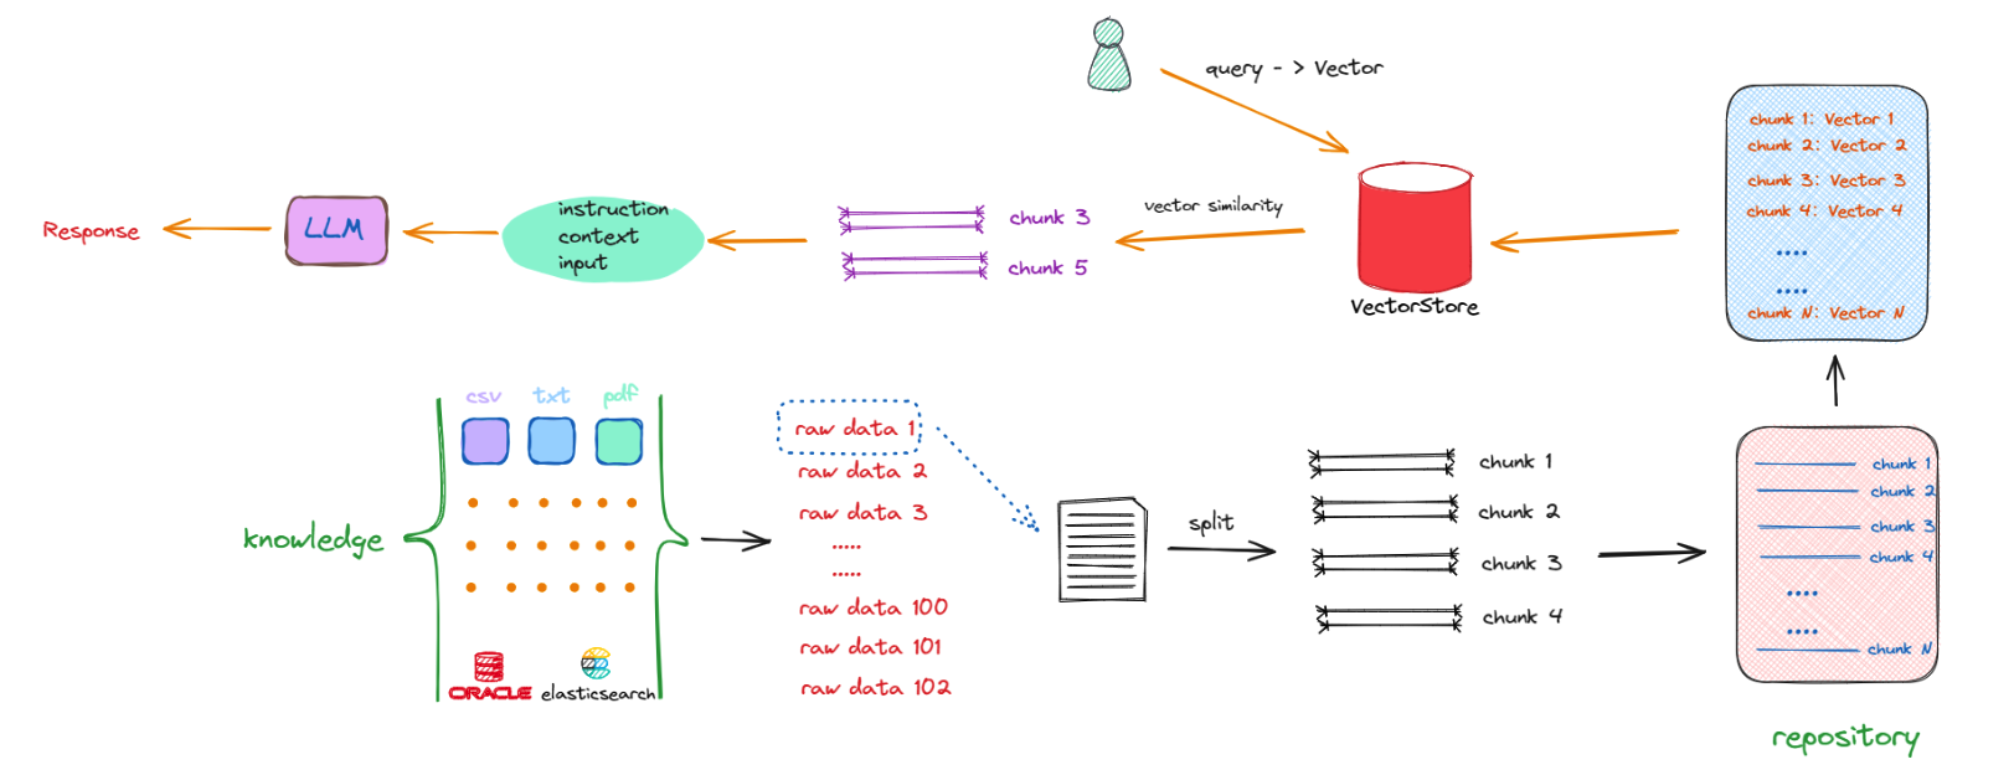

一个基础的RAG架构会只要包含以下几方面的开发工作：

1. 如何将原始数据转化成chunks；
2. 如何将chunks转化成Vector；
3. 如何选择计算向量相似度的算法；
4. 如何利用向量数据库提升搜索效率；
5. 如何把找到的chunks与原始query拼接在一起，产生最终的Prompt；

在以上5点开发任务中，我们确实是可以利用已经训练好的Embedding模型，开源的向量数据库等去直接解决某一类问题，所以我们前面才说一个基础架构的RAG系统搭建起来其实很简单，但搭建并不意味着直接就能用，毕竟RAG的核心是检索，检索出来的内容的准确率是衡量一个RAG系统的最基础的标准。目前没有任何一套理论、任何一套解决方案能够百分之百的指导着我们构建出一个最优的RAG系统。不同的需求，不同的数据，其构建方法也会大相径庭，需要我们在实践的过程中不断地去尝试，不断地去积累相关的经验，才能够将其真正落地。

**代码构建简易RAG**

pip install chromadb

pip install requests

#### 如何将文本切分成Chunks

分块（Chunking），其实现形式上是将长文档拆分为较小的块的过程，目的是在检索时能够准确地找到最直接和最相关的段落。由于文章通常包含大量不相关信息，在进行分块之前，也常常需要进行一些预处理工作，如文本清洗、停用词处理等。

转回到核心内容来看，一个有效的分块策略，可以确保搜索结果精确地反映用户查询的实际需求。如果分块过小或过大，都可能导致搜索结果不准确或提取不到最相关的内容。理想的文本块应尽可能语义独立，即不过度依赖上下文，这样的文本是语言模型最易于理解的。因此，为文档确定最佳的块大小是确保搜索结果准确性和相关性的关键。这涉及多个决策因素，如块的大小；如果句子太短，模型可能难以理解其意义，且句子越短，包含的有效信息就越少。比较常用的有如下4种不同的方法来优化分块策略：

1. **根据句子切分**：这种方法按照自然句子边界进行切分，以保持语义完整性。
2. **按照固定字符数来切分**：这种策略根据特定的字符数量来划分文本，但可能会在不适当的位置切断句子。
3. **按固定字符数来切分，结合重叠窗口（overlapping windows）**：此方法与按字符数切分相似，但通过重叠窗口技术避免切分关键内容，确保信息连贯性。
4. **递归方法**：通过递归方式动态确定切分点，这种方法可以根据文档的复杂性和内容密度来调整块的大小。

第二种方法（按照字符数切分）和第三种方法（按固定字符数切分结合重叠窗口）主要基于字符进行文本的切分，而不考虑文章的实际内容和语义。这种方式虽简单，但可能会导致主题或语义上的断裂。相对而言，递归方法更加灵活和高效，它结合了固定长度切分和语义分析。通常是首选策略，因为它能够更好地确保每个段落包含一个完整的主题。

这些方法各有优势和局限，选择适当的分块策略取决于具体的应用需求和预期的检索效果。接下来我们依次尝试用常规手段应该如何实现上述几种方法的文本切分。

接下来就具体来上上述4中切分方式的具体实现~

#### 按照句子切分

按照句子切分，其实就是通过标点符号来进行文本切分（分割），这可以直接使用Python的标准库来完成这个任务。一种简单的方法是使用re模块，它提供了正则表达式的支持，可以方便地根据标点符号来分割文本。如下示例中，展示了如何使用re.split()函数来根据中文和英文的标点符号进行文本切分。代码如下：

#### 按照固定字符数切分

如果想按照固定字符数来切分文本，这种方法就不再依赖于标点符号，而是简单地按照给定的字符数来切分文本。我们可以编写一个函数，用来将文本分割成指定长度的片段。代码如下：

#### 结合重叠窗口的固定字符数切分

重复窗口的意义是：块之间保持一些重叠，以确保语义上下文不会在块之间丢失。在文本处理和其他数据分析领域，"重叠"（overlap）指的是连续数据块之间共享的部分。这种方法特别常见于信号处理、语音分析、自然语言处理等领域，其中数据的连续性和上下文信息非常重要。比如下述代码所示：

#### 递归字符文本切分

在前面讲的三种切分方法，虽然简单且更容易理解，但其存在的核心问题是：完全忽视了文档的结构，只是单纯按固定字符数量进行切分。所以难免要更进一步地去做优化，那么一个更进阶的文本分割器应该具备的是：

- 能够将文本分成小的、具有语义意义的块（通常是句子）。
- 可以通过某些测量方法，将这些小块组合成一个更大的块，直到达到一定的大小。
- 一旦达到该大小，请将该块设为自己的文本片段，然后创建具有一些重叠的新文本块，以保持块之间的上下文。

根据上述需求，衍生出来的就是递归字符文本切分器，在langChain中的抽象类为：`RecursiveCharacterTextSplitter`，同时它也是Langchain的默认文本分割器。

**文档切分的可视化工具**

我们可以用LangChain提供的文本切分可视化小工具进行直观的理解：https://langchain-text-splitter.streamlit.app/

#### langchain中的Text Splitters设计

我们首先需要明确的是：在RAG流程中，我们不仅仅处理原始字符串，更常见的是处理文档。文档不仅包含我们关注的文本，还包括额外的元数据（文档标题、发布日期、摘要或者作者信息等），而这两点，均在LangChain的Document Loader的设计中通过 Document对象的Page_content和metadata设定中进行了定义。所以`TextSplitter`的核心不仅仅是为了划分数据块，而是要以一种便于日后检索和提取价值的格式来整理我们的数据。那么这里我们首先要进行探索的就是：如何去接收不同的数据形式，并能够按照预定的切分方式进行切分。

下面我们就具体来看在langchain中对于Text Splitters是如何进行设计和实现的。

#### CharacterTextSplitter

这是最简单的方法。其基于字符（默认为“”）进行分割，并通过字符数来测量块长度。要使用该方法，需要先进行导入：

**split_text进行文本切分：**

1. **chunk_size**: 每个块的最大字符数为 100。
2. **chunk_overlap**: 相邻两个块之间会有 20 个字符的重叠部分。这是为了确保在处理或分析时，相邻块之间有足够的上下文信息。

**split_documents进行切分**

要使用`split_documents`方法，需要的是我们使用文档加载器，将`str`形式的文本数据先转换为`Document`对象，如下代码所示：

#### 词嵌入

LangChain 设计了一个 Embeddings 类，用来实现与Embedding Models的交互。

LangChain 中的 Embeddings 基类提供了两种方法：一种用于Embeddin文档对象，另一种用于Embdding查询（Query）。前者采用多个文本作为输入，而后者采用单个文本。

而我们前面说Embedding Models只需要学会如何去使用就可以，是因为有非常多的托管平台，如OpenAI、Hugging Face国内的有百川、千帆都提供了标准接口并集成在LangChian框架中，这意味着：Embedding Models已经有人帮我们训练好了，我们只要按照其提供的接口规范，将自然语言文本传入进去，就能得到其对应的向量表示。这显然是非常简单的。

那么在如此多的Embedding Models都可以使用的情况下，应该如何选择呢？ 首先，我们在使用形式上把 Embedding Models分为两类：

1. 在线Embedding Models，仅提供API服务，需要按照Token付费；
2. 开源Embedding Models可以下载到本地免费使用，但在运行过程中会消耗GPU资源。

接下来，我们也将围绕这两类不同类型的Embedding Models，逐一向大家介绍其在LangChain中的应用方法。

LangChain接入了国内的Baidu Qianfan，Baichuan Text Embeddings等向量模型。接下来我们以Baichuan Text Embeddings为例展开讲解。注意：Baichuan Text Embeddings目前仅支持中文文本嵌入。

**如何使用Baichuan Text Embeddings**

- 获取API Key

  - 要使用Baichuan Text Embeddings，首先需要获取API密钥。您可以通过以下步骤获取：
    - 访问[百川智能官方网站](https://platform.baichuan-ai.com/docs/text-Embedding)
    - 注册并创建一个账户
    - 在控制台中申请并获取API密钥

- 安装必要的库

  ``pip install langchain_community``

- 代码示例

- **BaichuanTextEmbeddings主要参数介绍：**

  - **api_key**

    - **参数名**：api_key

    - **参数取值**：需要用户在Baichuan官方平台注册后获取。

    - **作用**：这是调用Baichuan Text Embeddings服务的身份验证凭证。只有拥有有效API Key的用户才能访问和使用该模型进行文本嵌入操作。

  - **token_window_size**

    - **参数名**：token_window_size

    - **参数取值**：512

    - **作用**：这个参数决定了模型在处理文本时能够考虑的最大文本长度，即上下文窗口的大小。Baichuan Text Embeddings支持512个token的窗口大小，这意味着在对文本进行向量化表示时，会考虑每个文本片段中最多512个标记（token）的信息。较大的token窗口大小可以捕捉到更多的上下文信息，但会增加计算成本和内存消耗。
    - **原理**：模型通过考虑每个token及其周围一定范围内的其他token来构建语义表示。这些token的语义信息被融合在一起，形成一个富含上下文信息的向量表示。这种向量表示能够更好地反映文本的深层含义和结构特征。

  - **vector_dimension**

    - **参数名**：vector_dimension

    - **参数取值**：1024

    - **作用**：此参数指的是模型输出的向量空间的大小，Baichuan Text Embeddings生成的嵌入向量维度为1024维。高维度的向量能够更精细地表示文本的语义信息，提高模型的准确性和鲁棒性，使得模型能够更好地理解和区分不同的文本含义。

​		**BaichuanTextEmbeddings对象主要操作介绍：**

​		1.**向量查询**（**embed_query**）：该方法用于将单个文本嵌入为向量表示。它接受一个字符串类型		的文本作为输入，并返回该文本对应的向量表示。这个向量是一个高维向量（1024维），包含了		文本的语义信息，可以用于后续的各种自然语言处理任务。

​		2.**多向量查询**（**embed_documents**）：该方法用于将多个文本同时嵌入为向量表示。它接		受一个字符串列表作为输入，每个字符串都是一个文本，然后返回这些文本对应的向量表示列		表。这些向量也可以用于计算文本之间的相似度。

这里模拟一个QA场景，我们定义一个问题，然后定义10条文本作为回答。然后分别对问题和回答各自进行词向量转换：

**开源EMbedding Models**

ollama官网进行开源模型下载：https://ollama.com/search?q=embedding



我们以nomic-embed-text向量模型为例：

操作演示：

**计算向量之间的相似度**

- 点积（内积）: 两个向量的点积是一种衡量它们在同一方向上投影的大小的方法。如果两个向量是单位向量（长度为1），它们的点积等于它们之间夹角的余弦值。因此，点积经常被用来计算两个向量的相似度。
- 余弦相似度: 这是一种通过测量两个向量之间的角度来确定它们相似度的方法。余弦相似度是两个向量点积和它们各自长度乘积的商。这个值的范围从-1到1，其中1表示完全相同的方向，-1表示完全相反，0表示正交。
- 欧氏距离: 这种方法测量的是两个向量在n维空间中的实际距离。虽然它通常用于计算不相似度（即距离越大，不相似度越高），但可以通过某些转换（如取反数或用最大距离归一化）将其用于相似度计算。

像我们最常用的余弦相似度，其代码实现也非常简单，如下所示：

接下来，定义一个`get_embedding`函数，使用nomic向量模型来对文本生成向量。然后用定义好的`cosine_similarity`函数，使用余弦相似度计算两个文本间的相似度。

使用BaiChuan线上向量模型来对文本生成向量。然后用定义好的`cosine_similarity`函数，使用余弦相似度计算两个文本间的相似度。

**把向量化流程应用在LangChain的数据处理流中**

#### 向量数据库

目前市面上充斥着非常多的向量数据库，从整体上可以分为开源和闭源，当然闭源意味着我们需要付费使用，而对于开源的向量数据库来说，可以下载免费使用。通过官方的数据来看，最常用的向量数据库如下：
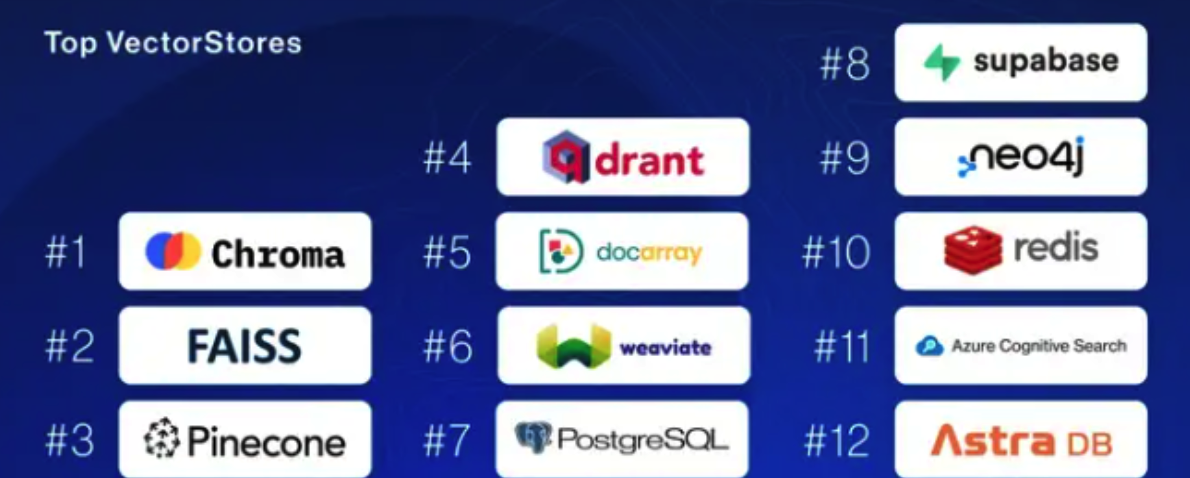

其中Chroma为LangChain官方主推的向量数据库，因此我们就以Chroma 为示例，尝试一下在LangChain中如何使用集成的向量数据库。Faiss与Chrom的使用方式基本保持一致，所以我们就不再重复的说明，大家可以根据官方文档，结合我们接下来对Chroma的实操自行尝试。

**Chroma的使用方法**

Chroma 是一家构建开源项目（也称为 Chroma）的公司，其官网：https://www.trychroma.com/

它支持用于搜索、过滤等的丰富功能，并能与多种平台和工具（如LangChain, LlamaIndex, OpenAI等）集成。Chroma的核心API包括四个命令，分别用于创建集合、添加文档、更新和删除，以及执行查询。Chroma向量数据库官方原生支持Python和JavaScript，也有其他语言的社区版本支持。所以可以直接通过Python或JS操作，具体的操作文档可查阅其官方：https://docs.trychroma.com/

在使用时，因为Chroma是作为第三方集成，所以需要安装依赖包，执行如下代码：

`` pip install langchain-chroma``

### RAG实战项目实践

**具体操作：**

